<a href="https://colab.research.google.com/github/PrishitaM/Employee-Attrition-Prediction-ML/blob/main/HR_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement**

### Business Context

McCurr Consultancy is an MNC that has thousands of employees spread across the globe. The company believes in hiring the best talent available and retaining them for as long as possible. A huge amount of resources is spent on retaining existing employees through various initiatives. The Head of People Operations wants to bring down the cost of retaining employees. For this, he proposes limiting the incentives to only those employees who are at risk of attrition. As a recently hired Data Scientist in the People Operations Department, you have been asked to identify patterns in characteristics of employees who leave the organization. Also, you have to use this information to predict if an employee is at risk of attrition. This information will be used to target them with incentives.

### Objective

You, as a Data Scientist at McCurr Consultancy, are tasked with analyzing the data provided to identify the different factors that drive attrition, and build a model that can help to predict attrition.

### Dataset

The data contains demographic details, work-related metrics and attrition flag.

* EmployeeNumber - Employee Identifier
* Attrition - Did the employee attrite?
* Age - Age of the employee
* BusinessTravel - Travel commitments for the job
* DailyRate - Data description not available
* Department - Employee Department
* DistanceFromHome - Distance from work to home (in km)
* Education - 1-Below College, 2-College, 3-Bachelor, 4-Master, 5-Doctor
* EducationField - Field of Education
* EmployeeCount - Employee Count in a row
* EnvironmentSatisfaction - 1-Low, 2-Medium, 3-High, 4-Very High
* Gender - Employee's gender
* HourlyRate - Data description not available
* JobInvolvement - 1-Low, 2-Medium, 3-High, 4-Very High
* JobLevel - Level of job (1 to 5)
* JobRole - Job Roles
* JobSatisfaction - 1-Low, 2-Medium, 3-High, 4-Very High
* MaritalStatus - Marital Status
* MonthlyIncome - Monthly Salary
* MonthlyRate - Data description not available
* NumCompaniesWorked - Number of companies worked at
* Over18 - Over 18 years of age?
* OverTime - Overtime?
* PercentSalaryHike - The percentage increase in salary last year
* PerformanceRating - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
* RelationshipSatisfaction - 1-Low, 2-Medium, 3-High, 4-Very High
* StandardHours - Standard Hours
* StockOptionLevel - Stock Option Level
* TotalWorkingYears - Total years worked
* TrainingTimesLastYear - Number of training attended last year
* WorkLifeBalance - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
* YearsAtCompany - Years at Company
* YearsInCurrentRole - Years in the current role
* YearsSinceLastPromotion - Years since the last promotion
* YearsWithCurrManager - Years with the current manager

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_csv('/content/HR_Employee_Attrition-1.csv')

In [4]:
df.head()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,2,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,3,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,4,No,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,5,No,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.tail()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2935,2936,No,36,Travel_Frequently,884,Research & Development,23,2,Medical,1,...,3,80,1,17,3,3,5,2,0,3
2936,2937,No,39,Travel_Rarely,613,Research & Development,6,1,Medical,1,...,1,80,1,9,5,3,7,7,1,7
2937,2938,No,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,...,2,80,1,6,0,3,6,2,0,3
2938,2939,No,49,Travel_Frequently,1023,Sales,2,3,Medical,1,...,4,80,0,17,3,2,9,6,0,8
2939,2940,No,34,Travel_Rarely,628,Research & Development,8,3,Medical,1,...,1,80,0,6,3,4,4,3,1,2


In [6]:
df.shape

(2940, 35)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            2940 non-null   int64 
 1   Attrition                 2940 non-null   object
 2   Age                       2940 non-null   int64 
 3   BusinessTravel            2940 non-null   object
 4   DailyRate                 2940 non-null   int64 
 5   Department                2940 non-null   object
 6   DistanceFromHome          2940 non-null   int64 
 7   Education                 2940 non-null   int64 
 8   EducationField            2940 non-null   object
 9   EmployeeCount             2940 non-null   int64 
 10  EnvironmentSatisfaction   2940 non-null   int64 
 11  Gender                    2940 non-null   object
 12  HourlyRate                2940 non-null   int64 
 13  JobInvolvement            2940 non-null   int64 
 14  JobLevel                

In [8]:
df.describe()

,EmployeeNumber,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.0,2940.000000,2940.000000,2940.000000,2940.000000,...,2940.000000,2940.0,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000
mean,1470.500000,36.923810,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,848.849221,9.133819,403.440447,8.105485,1.023991,0.0,1.092896,20.325969,0.711440,1.106752,...,1.081025,0.0,0.851932,7.779458,1.289051,0.706356,6.125483,3.622521,3.221882,3.567529
min,1.000000,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,735.750000,30.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,1470.500000,36.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,2205.250000,43.000000,1157.000000,14.000000,4.000000,1.0,4.000000,84.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,2940.000000,60.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
df.isnull().sum()

,0
EmployeeNumber,0
Attrition,0
Age,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0


**Observations -**
* The dataset has 2940 rows and 35 columns.
* There are no null values.
* EmployeeCount, StandardHours, Over18, and EmployeeNumber do not add useful information.

**Dropping columns that do not add useful information**

In [10]:
df = df.drop(['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'], axis=1)

In [11]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
count,2940,2940,2940,2940,2940,2940,2940,2940
unique,2,3,3,6,2,9,3,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,No
freq,2466,2086,1922,1212,1764,652,1346,2108


**Observations -**
* Attrition is our target variable - 84% are 'No'.
* Majority of employees have low business travel requirements.
* Majority are from the R&D department.

## **Exploratory Data Analysis**

**Target Variable**

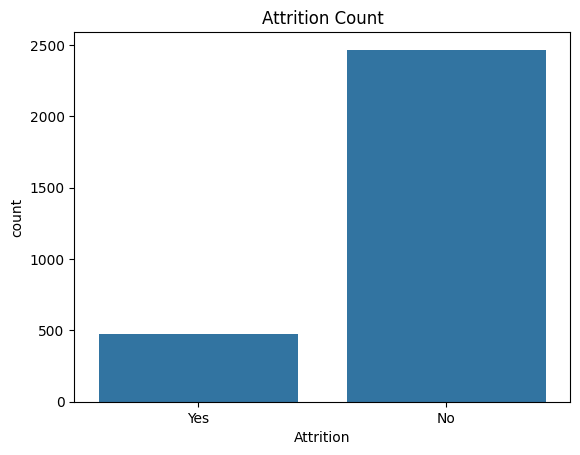

In [12]:
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Count')
plt.show()

* 16% of employees attrite. The data is imbalanced.

### Univariate Analysis

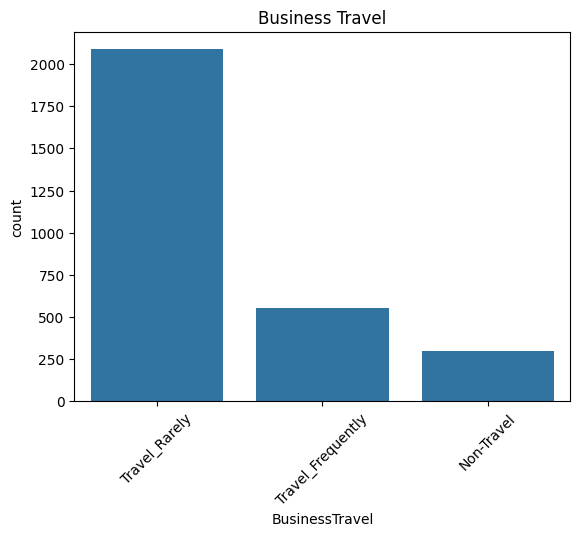

In [13]:
sns.countplot(x='BusinessTravel', data=df)
plt.title('Business Travel')
plt.xticks(rotation=45)
plt.show()

* 71% of employees travel rarely.

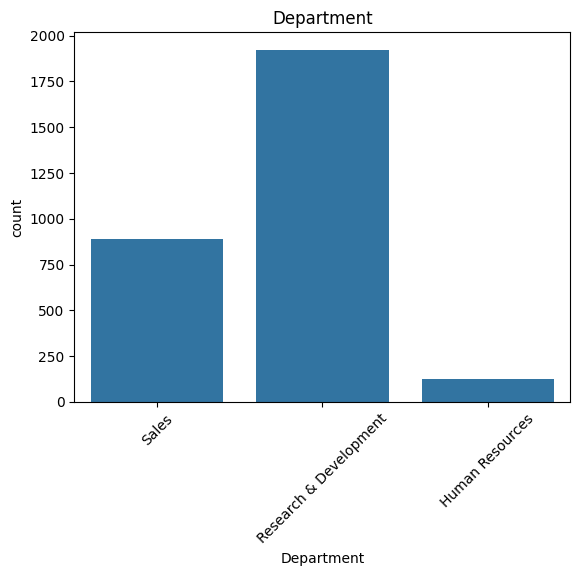

In [14]:
sns.countplot(x='Department', data=df)
plt.title('Department')
plt.xticks(rotation=45)
plt.show()

* 65% of employees are from R&D.

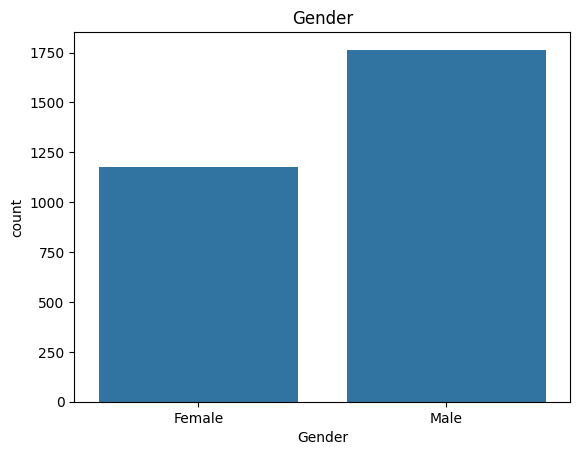

In [15]:
sns.countplot(x='Gender', data=df)
plt.title('Gender')
plt.show()

* 60% male, 40% female.

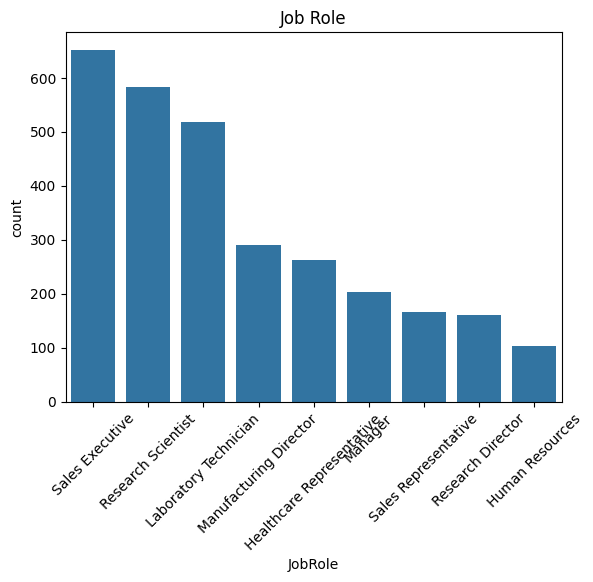

In [16]:
sns.countplot(x='JobRole', data=df)
plt.title('Job Role')
plt.xticks(rotation=45)
plt.show()

* 22.2% are Sales Executives followed by 20% Research Scientists.

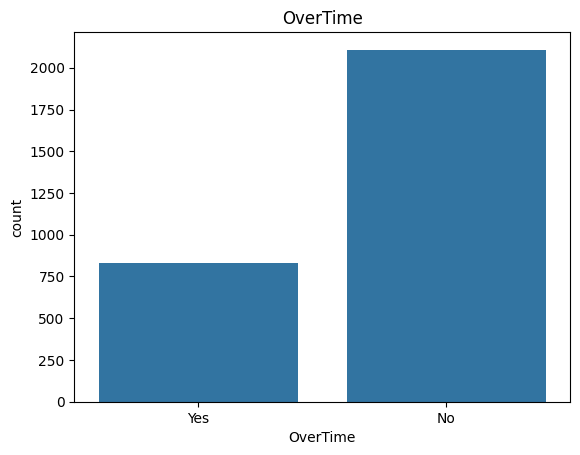

In [17]:
sns.countplot(x='OverTime', data=df)
plt.title('OverTime')
plt.show()

* 71.7% do not work overtime.

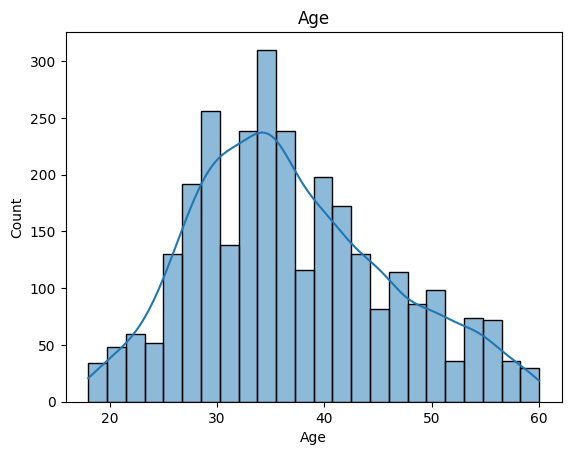

In [18]:
sns.histplot(df['Age'], kde=True)
plt.title('Age')
plt.show()

* Age is approximately normally distributed. Average age is 37.

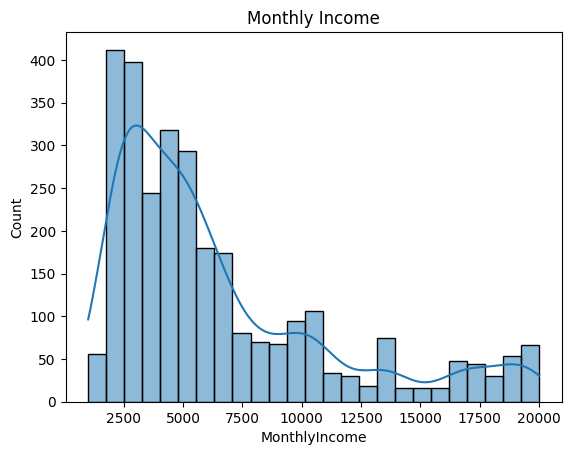

In [19]:
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title('Monthly Income')
plt.show()

* Monthly income is right-skewed. There are some high earners.

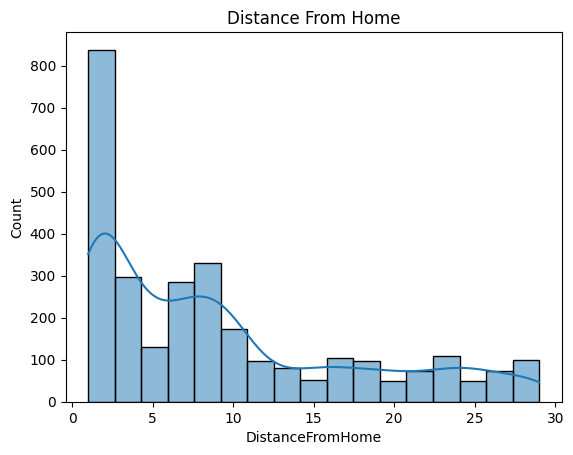

In [20]:
sns.histplot(df['DistanceFromHome'], kde=True)
plt.title('Distance From Home')
plt.show()

* Most employees live close to the office.

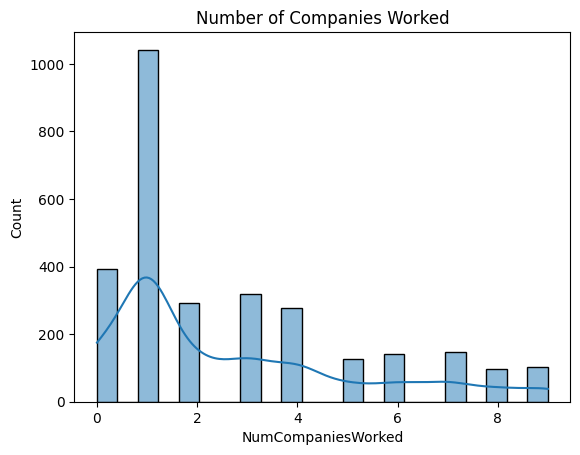

In [21]:
sns.histplot(df['NumCompaniesWorked'], kde=True)
plt.title('Number of Companies Worked')
plt.show()

* Most employees have worked at only 1 company before.

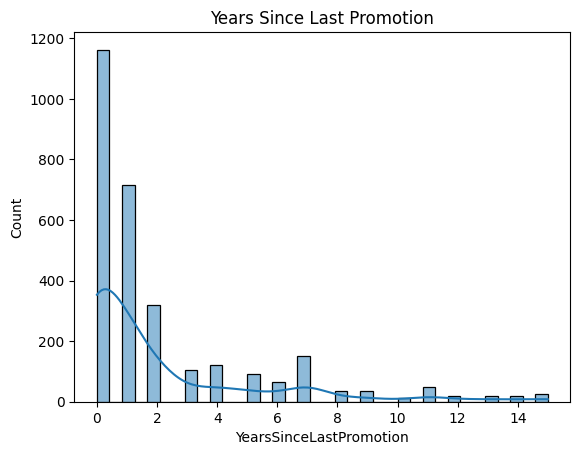

In [22]:
sns.histplot(df['YearsSinceLastPromotion'], kde=True)
plt.title('Years Since Last Promotion')
plt.show()

* Most employees were recently promoted.

### Bivariate Analysis

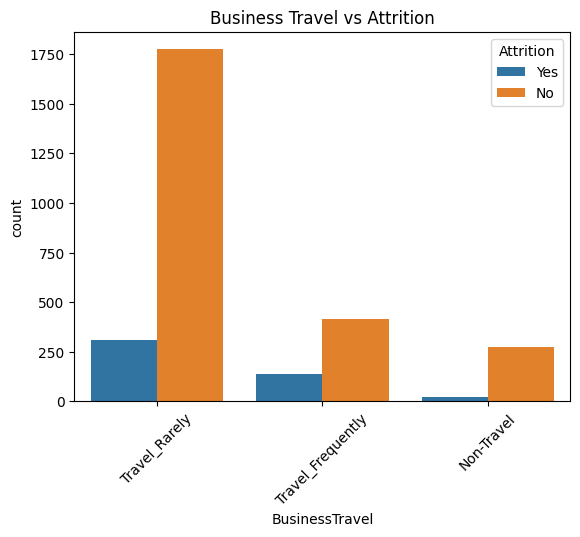

In [23]:
sns.countplot(x='BusinessTravel', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title('Business Travel vs Attrition')
plt.show()

* Attrition rate increases with travel frequency. ~22% for frequent travelers.

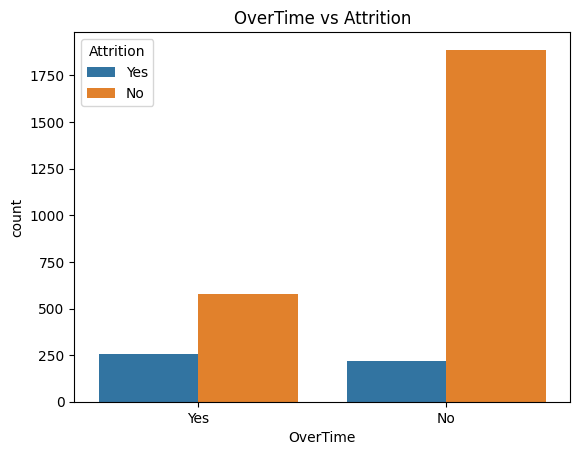

In [24]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('OverTime vs Attrition')
plt.show()

* ~35% of employees working overtime attrite.

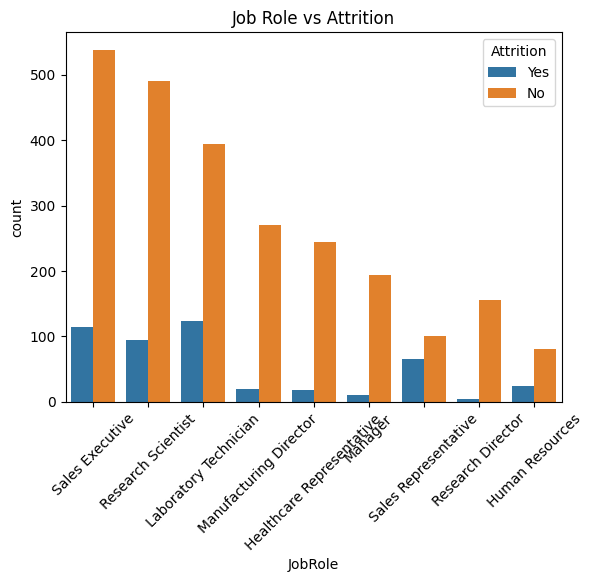

In [25]:
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title('Job Role vs Attrition')
plt.show()

* Sales Executives have the highest attrition probability (>40%).

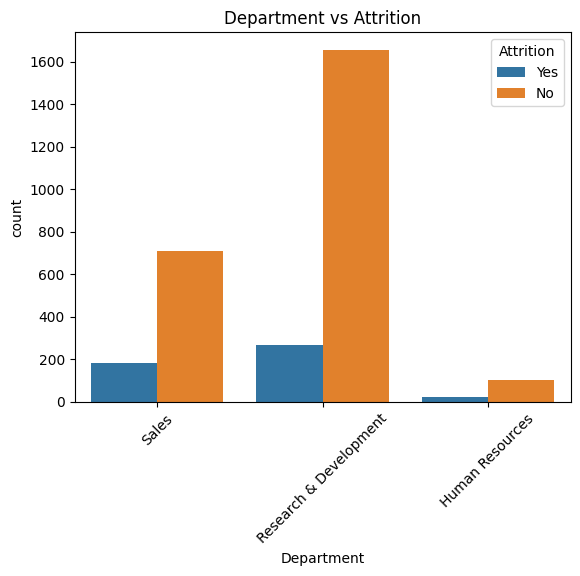

In [26]:
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title('Department vs Attrition')
plt.show()

* Sales and HR have the highest attrition rates.

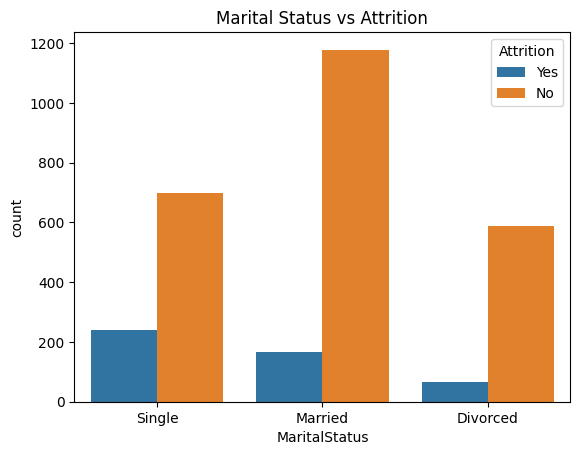

In [27]:
sns.countplot(x='MaritalStatus', hue='Attrition', data=df)
plt.title('Marital Status vs Attrition')
plt.show()

* Single employees attrite more than married or divorced ones.

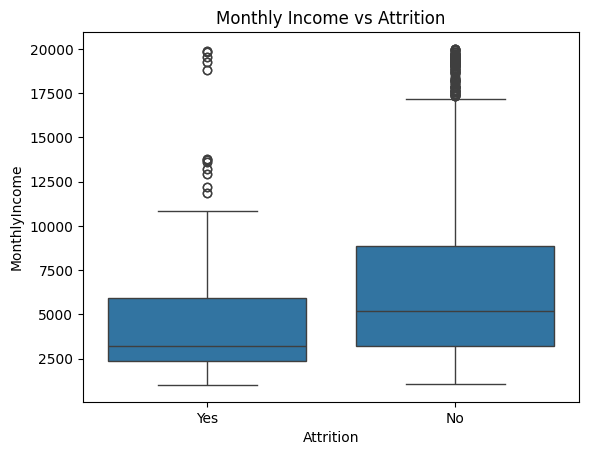

In [28]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

* Employees with lower monthly income are more likely to attrite.

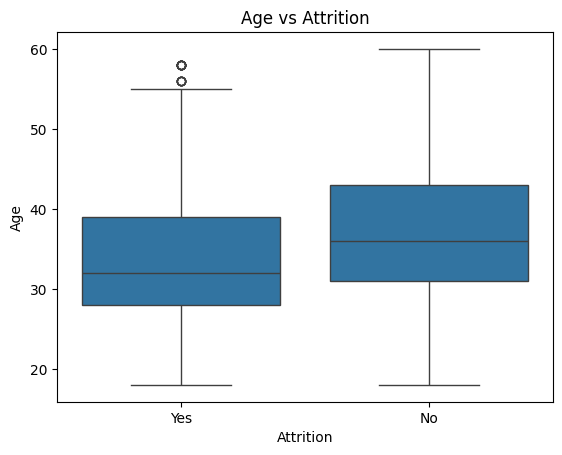

In [29]:
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title('Age vs Attrition')
plt.show()

* Younger employees have a higher attrition rate.

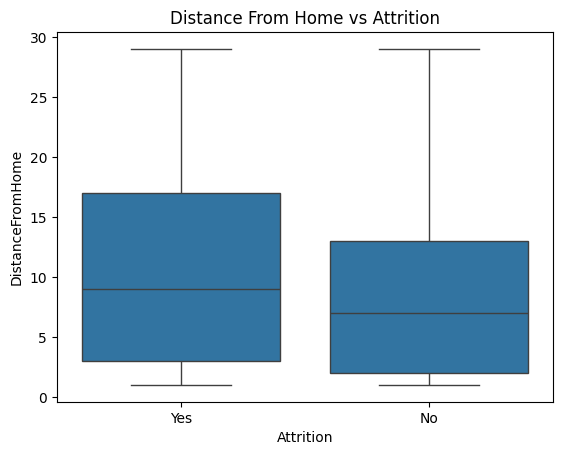

In [30]:
sns.boxplot(x='Attrition', y='DistanceFromHome', data=df)
plt.title('Distance From Home vs Attrition')
plt.show()

* Employees who commute longer distances attrite more.

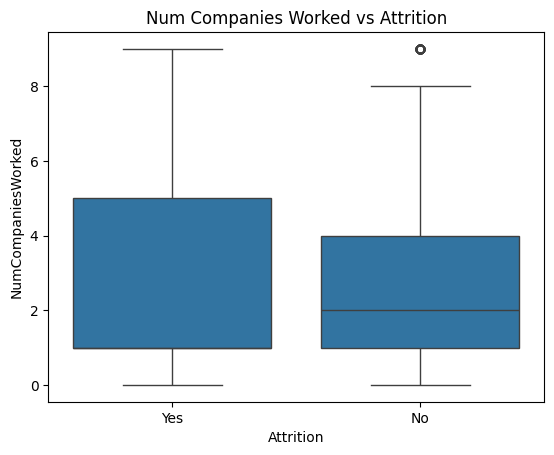

In [31]:
sns.boxplot(x='Attrition', y='NumCompaniesWorked', data=df)
plt.title('Num Companies Worked vs Attrition')
plt.show()

* Employees who have worked at more companies are more likely to attrite.

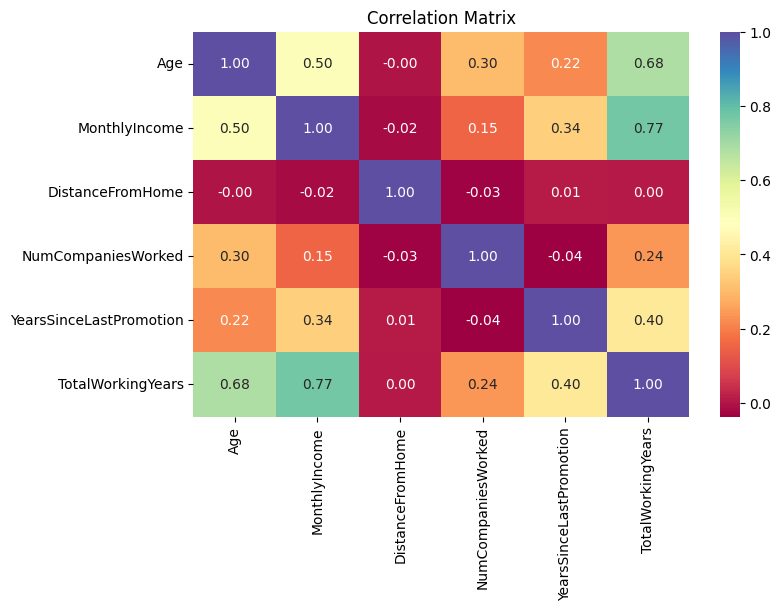

In [32]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Age', 'MonthlyIncome', 'DistanceFromHome', 'NumCompaniesWorked', 'YearsSinceLastPromotion', 'TotalWorkingYears']].corr(), annot=True, fmt='.2f', cmap='Spectral')
plt.title('Correlation Matrix')
plt.show()

* TotalWorkingYears and MonthlyIncome are highly correlated.
* No major multicollinearity issues between key features.

## **Data Preprocessing**

**Encoding the target variable and categorical features**

In [33]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [34]:
df = pd.get_dummies(df, drop_first=True)

**Train-Test Split**

In [35]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
print(X_train.shape, X_test.shape)

(2058, 44) (882, 44)


In [36]:
y.value_counts(normalize=True)

,proportion
Attrition,
0,0.838776
1,0.161224


* The target is imbalanced - 84% No, 16% Yes. We will handle this with SMOTE and Undersampling.

**Outlier Treatment**

In [37]:
num_cols = ['MonthlyIncome', 'NumCompaniesWorked', 'DistanceFromHome', 'TotalWorkingYears']

for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_train[col] = np.clip(X_train[col], lower, upper)
    X_test[col] = np.clip(X_test[col], lower, upper)

## **Model Building**

### Model Evaluation Criterion
* Predicting an employee will NOT attrite but they DO attrite means losing a valuable employee.
* **Goal: Maximize Recall** to minimize false negatives.

**Importing model libraries**

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

### Model Building (Original Data)

**Decision Tree**

In [39]:
dt = DecisionTreeClassifier(class_weight={0:0.17, 1:0.83}, random_state=1)
dt.fit(X_train, y_train)

train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9365079365079365
Test Recall: 0.8309859154929577
[[708  32]
 [ 24 118]]


**Bagging**

In [40]:
bag = BaggingClassifier(DecisionTreeClassifier(class_weight={0:0.17, 1:0.83}, random_state=1), random_state=1)
bag.fit(X_train, y_train)

train_pred = bag.predict(X_train)
test_pred = bag.predict(X_test)

print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Train Accuracy: 0.9931972789115646
Test Accuracy: 0.9387755102040817
Test Recall: 0.6901408450704225
[[730  10]
 [ 44  98]]


**Random Forest**

In [41]:
rf = RandomForestClassifier(class_weight={0:0.17, 1:0.83}, random_state=1)
rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9591836734693877
Test Recall: 0.7887323943661971
[[734   6]
 [ 30 112]]


**AdaBoost**

In [42]:
ada = AdaBoostClassifier(random_state=1)
ada.fit(X_train, y_train)

train_pred = ada.predict(X_train)
test_pred = ada.predict(X_test)

print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Train Accuracy: 0.89067055393586
Test Accuracy: 0.8832199546485261
Test Recall: 0.33098591549295775
[[732   8]
 [ 95  47]]


**Gradient Boosting**

In [43]:
gb = GradientBoostingClassifier(random_state=1)
gb.fit(X_train, y_train)

train_pred = gb.predict(X_train)
test_pred = gb.predict(X_test)

print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Train Accuracy: 0.9552964042759962
Test Accuracy: 0.9047619047619048
Test Recall: 0.4859154929577465
[[729  11]
 [ 73  69]]


### Oversampling (SMOTE)

In [46]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=1)
X_train_os, y_train_os = sm.fit_resample(X_train, y_train)
print(y_train_os.value_counts())

Attrition
0    1726
1    1726
Name: count, dtype: int64


**Decision Tree**

In [45]:
dt.fit(X_train_os, y_train_os)
test_pred = dt.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.9229024943310657
Test Recall: 0.8450704225352113
[[694  46]
 [ 22 120]]


**Bagging**

In [47]:
bag.fit(X_train_os, y_train_os)
test_pred = bag.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.9331065759637188
Test Recall: 0.7464788732394366
[[717  23]
 [ 36 106]]


**Random Forest**

In [48]:
rf.fit(X_train_os, y_train_os)
test_pred = rf.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.9614512471655329
Test Recall: 0.8169014084507042
[[732   8]
 [ 26 116]]


**AdaBoost**

In [49]:
ada.fit(X_train_os, y_train_os)
test_pred = ada.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.8367346938775511
Test Recall: 0.6690140845070423
[[643  97]
 [ 47  95]]


**Gradient Boosting**

In [50]:
gb.fit(X_train_os, y_train_os)
test_pred = gb.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.9058956916099773
Test Recall: 0.5845070422535211
[[716  24]
 [ 59  83]]


### Undersampling

In [51]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=1)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)
print(y_train_us.value_counts())

Attrition
0    332
1    332
Name: count, dtype: int64


**Decision Tree**

In [52]:
dt.fit(X_train_us, y_train_us)
test_pred = dt.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.7743764172335601
Test Recall: 0.8873239436619719
[[557 183]
 [ 16 126]]


**Bagging**

In [53]:
bag.fit(X_train_us, y_train_us)
test_pred = bag.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.8696145124716553
Test Recall: 0.852112676056338
[[646  94]
 [ 21 121]]


**Random Forest**

In [54]:
rf.fit(X_train_us, y_train_us)
test_pred = rf.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.8718820861678005
Test Recall: 0.8873239436619719
[[643  97]
 [ 16 126]]


**AdaBoost**

In [55]:
ada.fit(X_train_us, y_train_us)
test_pred = ada.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.7743764172335601
Test Recall: 0.7887323943661971
[[571 169]
 [ 30 112]]


**Gradient Boosting**

In [56]:
gb.fit(X_train_us, y_train_us)
test_pred = gb.predict(X_test)

print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.8072562358276644
Test Recall: 0.8591549295774648
[[590 150]
 [ 20 122]]


## **Hyperparameter Tuning**

In [57]:
from sklearn.model_selection import RandomizedSearchCV

**Decision Tree**

In [58]:
params_dt = {
    'max_depth': [7, 8, 9],
    'min_samples_leaf': [8, 10, 12],
    'max_leaf_nodes': [14, 15, 16],
    'class_weight': [{0:0.15, 1:0.85}, {0:0.17, 1:0.83}, {0:0.20, 1:0.80}]
}

dt = DecisionTreeClassifier(random_state=1)
rand_dt = RandomizedSearchCV(dt, params_dt, scoring='recall', cv=3, random_state=1)
rand_dt.fit(X_train, y_train)
best_dt = rand_dt.best_estimator_

test_pred = best_dt.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.780045351473923
Test Recall: 0.676056338028169
[[592 148]
 [ 46  96]]


**Bagging**

In [59]:
params_bag = {
    'n_estimators': [25, 30, 35],
    'max_features': [0.8, 0.9, 1.0],
    'max_samples': [0.8, 0.9, 1.0]
}

bag = BaggingClassifier(DecisionTreeClassifier(class_weight={0:0.13, 1:0.87}, random_state=1), random_state=1)
rand_bag = RandomizedSearchCV(bag, params_bag, scoring='recall', cv=3, random_state=1)
rand_bag.fit(X_train, y_train)
best_bag = rand_bag.best_estimator_

test_pred = best_bag.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.9501133786848073
Test Recall: 0.7605633802816901
[[730  10]
 [ 34 108]]


**Random Forest**

In [60]:
params_rf = {
    'n_estimators': [75, 100, 125],
    'max_features': [0.8, 0.9, 1.0],
    'max_samples': [0.8, 0.9, 1.0],
    'class_weight': [{0:0.17, 1:0.83}]
}

rf = RandomForestClassifier(random_state=1)
rand_rf = RandomizedSearchCV(rf, params_rf, scoring='recall', cv=3, random_state=1)
rand_rf.fit(X_train, y_train)
best_rf = rand_rf.best_estimator_

test_pred = best_rf.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.9569160997732427
Test Recall: 0.8028169014084507
[[730  10]
 [ 28 114]]


**AdaBoost**

In [61]:
params_ada = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0]
}

ada = AdaBoostClassifier(random_state=1)
rand_ada = RandomizedSearchCV(ada, params_ada, scoring='recall', cv=3, random_state=1)
rand_ada.fit(X_train, y_train)
best_ada = rand_ada.best_estimator_

test_pred = best_ada.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Test Accuracy: 0.8832199546485261
Test Recall: 0.36619718309859156
[[727  13]
 [ 90  52]]


**Gradient Boosting**

In [62]:
params_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb = GradientBoostingClassifier(random_state=1)
rand_gb = RandomizedSearchCV(gb, params_gb, scoring='recall', cv=3, random_state=1)
rand_gb.fit(X_train, y_train)
best_gb = rand_gb.best_estimator_

test_pred = best_gb.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print('Test Recall:', recall_score(y_test, test_pred))
print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.95578231292517
Test Recall: 0.823943661971831
[[726  14]
 [ 25 117]]


## **Model Performance Comparison**

In [63]:
results = {}

In [64]:
dt.fit(X_train, y_train)
bag.fit(X_train, y_train)
rf.fit(X_train, y_train)
ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1)

In [65]:
for name, model in [('DT_Original', dt), ('Bagging_Original', bag),
                     ('RF_Original', rf), ('AdaBoost_Original', ada), ('GB_Original', gb)]:
    y_pred = model.predict(X_test)
    results[name] = [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                     recall_score(y_test, y_pred), f1_score(y_test, y_pred)]

In [66]:
dt.fit(X_train_os, y_train_os)
bag.fit(X_train_os, y_train_os)
rf.fit(X_train_os, y_train_os)
ada.fit(X_train_os, y_train_os)
gb.fit(X_train_os, y_train_os)

for name, model in [('DT_SMOTE', dt), ('Bagging_SMOTE', bag),
                     ('RF_SMOTE', rf), ('AdaBoost_SMOTE', ada), ('GB_SMOTE', gb)]:
    y_pred = model.predict(X_test)
    results[name] = [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                     recall_score(y_test, y_pred), f1_score(y_test, y_pred)]

In [67]:
dt.fit(X_train_us, y_train_us)
bag.fit(X_train_us, y_train_us)
rf.fit(X_train_us, y_train_us)
ada.fit(X_train_us, y_train_us)
gb.fit(X_train_us, y_train_us)

for name, model in [('DT_Undersample', dt), ('Bagging_Undersample', bag),
                     ('RF_Undersample', rf), ('AdaBoost_Undersample', ada), ('GB_Undersample', gb)]:
    y_pred = model.predict(X_test)
    results[name] = [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                     recall_score(y_test, y_pred), f1_score(y_test, y_pred)]

In [68]:
for name, model in [('DT_Tuned', best_dt), ('Bagging_Tuned', best_bag),
                     ('RF_Tuned', best_rf), ('AdaBoost_Tuned', best_ada), ('GB_Tuned', best_gb)]:
    y_pred = model.predict(X_test)
    results[name] = [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                     recall_score(y_test, y_pred), f1_score(y_test, y_pred)]

In [69]:
comparison_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])
print('Model Performance Comparison:')
comparison_df

Model Performance Comparison:


,DT_Original,Bagging_Original,RF_Original,AdaBoost_Original,GB_Original,DT_SMOTE,Bagging_SMOTE,RF_SMOTE,AdaBoost_SMOTE,GB_SMOTE,DT_Undersample,Bagging_Undersample,RF_Undersample,AdaBoost_Undersample,GB_Undersample,DT_Tuned,Bagging_Tuned,RF_Tuned,AdaBoost_Tuned,GB_Tuned
Accuracy,0.941043,0.941043,0.961451,0.883220,0.904762,0.936508,0.939909,0.963719,0.836735,0.905896,0.775510,0.832200,0.869615,0.774376,0.807256,0.780045,0.950113,0.956916,0.883220,0.955782
Precision,0.816901,0.924528,0.950000,0.854545,0.862500,0.765432,0.850394,0.936508,0.494792,0.775701,0.412500,0.487603,0.557940,0.398577,0.448529,0.393443,0.915254,0.919355,0.800000,0.893130
Recall,0.816901,0.690141,0.802817,0.330986,0.485915,0.873239,0.760563,0.830986,0.669014,0.584507,0.929577,0.830986,0.915493,0.788732,0.859155,0.676056,0.760563,0.802817,0.366197,0.823944
F1 Score,0.816901,0.790323,0.870229,0.477157,0.621622,0.815789,0.802974,0.880597,0.568862,0.666667,0.571429,0.614583,0.693333,0.529551,0.589372,0.497409,0.830769,0.857143,0.502415,0.857143


In [70]:
best_model_name = comparison_df.loc['Recall'].idxmax()
print('Best Model (by Recall):', best_model_name)

Best Model (by Recall): DT_Undersample


## **Final Model - Feature Importance**

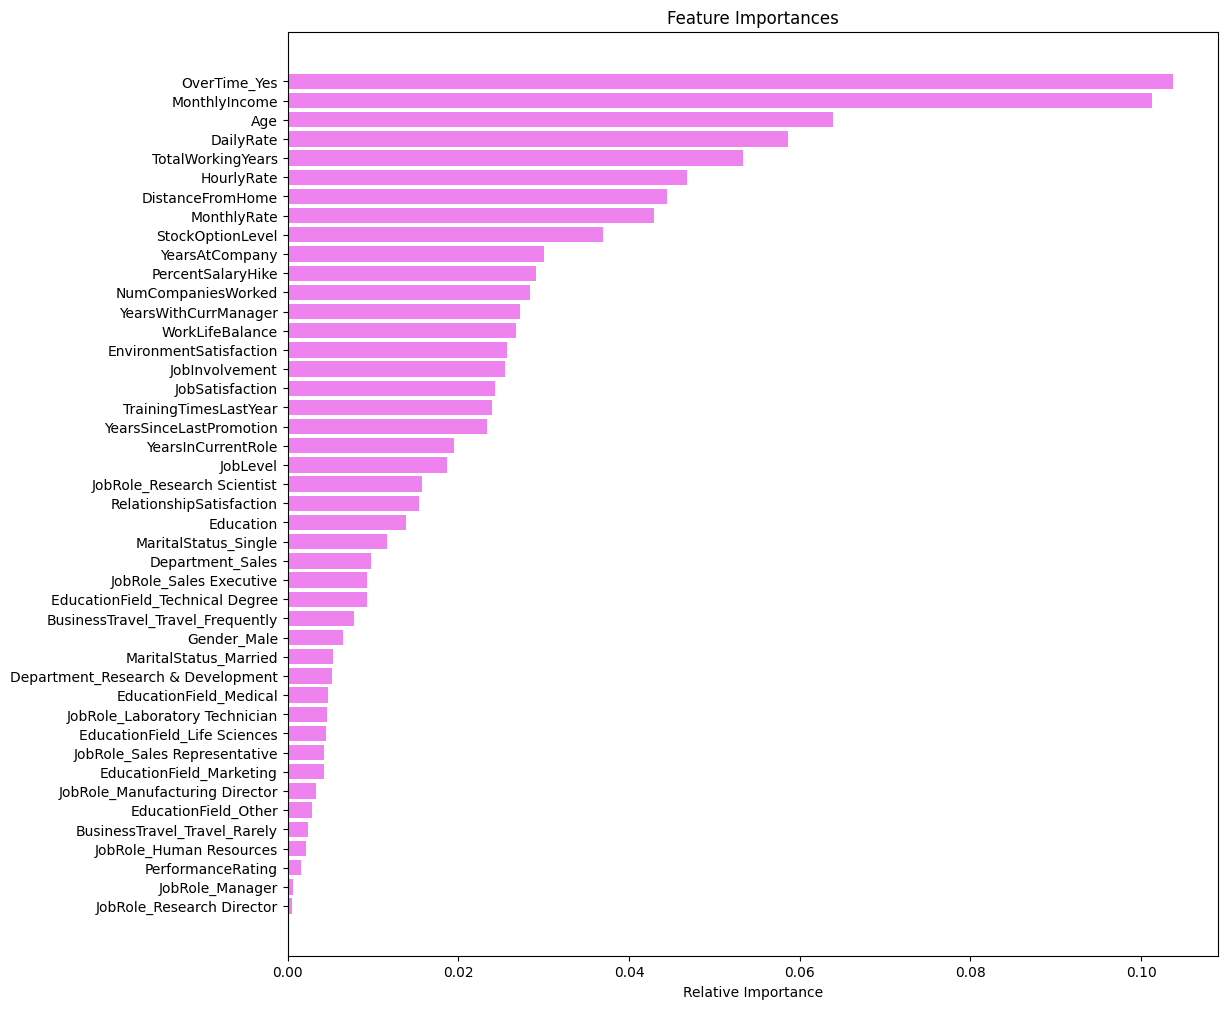

In [71]:
final_model = best_rf

importances = final_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

* Monthly income is the most important feature, followed by Overtime, Daily Rate, and Age.

## **Conclusions and Business Recommendations**

### Conclusions

1. The model can identify employees at risk of attrition.
2. Primary attrition drivers: low monthly income, overtime, younger age, long commute, frequent travel.
3. Sales and HR departments have the highest attrition rates.
4. Low satisfaction scores across environment, job, relationship, and work-life balance predict higher attrition.
5. Training has no clear impact on retention.

### Business Recommendations

1. Target retention incentives at employees flagged as high risk by the model.
2. Review compensation for employees earning below industry standards.
3. Provide transport support and reduce unnecessary work travel.
4. Create growth-friendly environments to retain younger employees.
5. Investigate high-attrition departments like Sales with focused strategies.
6. Provide additional benefits for employees consistently working overtime.